## 📌 Introduction

This notebook focuses on the **data exploration phase** . The main objectives of this exploration are to:

- Understand the overall structure and size of the dataset  
- Identify attribute types and key features  
- Assess data quality issues such as missing, inconsistent, or extreme values  
- Generate descriptive statistics for numerical and categorical attributes  
- Visualize data distributions and basic relationships between variables  
- Document initial observations to inform later preprocessing and data mining tasks  

At this stage, no data cleaning, transformation, or mining techniques are applied. The goal is solely to **understand the data** and prepare for subsequent analysis.


In [3]:
import pandas as pd 
df = pd.read_csv("../data/raw/Driving Data(KIA SOUL)_(150728-160714)_(10 Drivers_A-J).csv")
# print(df.columns.tolist())

# all_features = df.columns.tolist()
# len(all_features)

display(df['Fuel_Pressure'])

sampled_df = df.groupby("Class").apply(lambda x: x.sample(n=5, random_state=1)).reset_index(drop=True)

df_sorted = df.sort_values(by="Time(s)", ascending=True)
df_sorted_id = df.sort_values(by="Class", ascending=True)


class_counts = df["Engine_in_fuel_cut_off"].value_counts()
print(class_counts)



0        0
1        0
2        0
3        0
4        0
        ..
94375    0
94376    0
94377    0
94378    0
94379    0
Name: Fuel_Pressure, Length: 94380, dtype: int64

Engine_in_fuel_cut_off
0    88033
1     6347
Name: count, dtype: int64


C:\Users\idris\AppData\Local\Temp\ipykernel_9240\2120415679.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df.groupby("Class").apply(lambda x: x.sample(n=5, random_state=1)).reset_index(drop=True)




Each driver (A–J) has many rows because the data are recorded continuously over time. Each row represents sensor readings at a specific time instant, not a unique driver. Therefore, a single driver generates thousands of samples corresponding to different driving situations.



## 🛢️ Fuel & Air Management

- **Fuel_consumption:** Engine fuel usage, used to assess efficiency and emissions.

        Type : continuous and vals : [0.0, 10931.2]
- **Fuel_Pressure:** Fuel pressure supplied to injectors, affecting combustion quality.

        all values are 0 , lapobel 🗑️
- **Intake_air_pressure:** Air pressure entering the engine, indicating engine load.

        Type : discrete and vals :  [0, 178]

- **Calculated_LOAD_value:** Estimated engine load based on airflow and RPM (how hard the engine is working at a given moment).

        It is calculated by the ECU (Engine Control Unit) using inputs such as:
            . Airflow into the engine (Intake air pressure)
            . Engine speed (RPM)
            . Throttle position
            . Fuel injection or fuel pressure

        Type : continuous and vals : [0.0, 98.4]

## 🦶 Driver Input & Throttle (controls how much air enters the engine)

- **Accelerator_Pedal_value:** Raw accelerator pedal position showing driver demand.

        Type : continous and vals :  [0.0, 99.2]

- **Filtered_Accelerator_Pedal_value:** Smoothed accelerator signal for stable control(Accelerator_Pedal_value with filtering ).

        all values are 0 so 🗑️

- **Throttle_position_signal:** Throttle opening signal controlling air intake.

        Type : continuous and vals : [0.0, 100.0] 

- **Absolute_throttle_position:** Actual throttle plate position(physical angle of the throttle plate).

        Type : continuous and vals : [12.5, 84.3]


## 🔥 Fuel Trim & Combustion

    Term_Fuel : air–fuel mixture to be just right .
        - Air–fuel ratio (AFR) = ratio of air to fuel in the engine.
        - If it’s off, the ECU adjusts the fuel using fuel trims.

- **Short_Term_Fuel_Trim_Bank1:** Short-term fuel correction for air–fuel ratio control.

        Type : continuous and vals : [-15.6, 23.4]

- **Long_Term_Fuel_Trim_Bank1:** Long-term fuel correction compensating persistent deviations.

        Type : continuous and vals : [-1.6, 10.2]


- **Current_spark_timing:** Ignition timing affecting power and efficiency.

        Type : continuous and vals : [-35.6, 50.3]

## 🧠 Engine State

- **Engine_speed:** Engine speed in RPM(Revolutions Per Minute).

        Type : discrete and vals : [0, 6253]

- **Engine_Idel_Target_Speed:** Target RPM during idle.

        Type : discrete and vals : [0, 1550]

- **Engine_soacking_time:** Time engine remains heat-soaked after shutdown.

        Type : discrete and vals : [0, 255] (minutes)

- **Engine_coolant_temperature:** Engine coolant temperature indicating thermal state.

        temperature of the engine coolant (the liquid that circulates inside the engine to remove heat) , tell how cold or hot the engin is .

        Type : discrete and vals : [-40, 96] (°C)

- **Engine_coolant_temperature.1:** Redundant coolant temperature measurement(not duplicate , it has different values).
        Type : discrete and vals : [-40, 105] (°C)

## ⚙️ Torque & Power

- **Engine_torque:** Torque (Force) produced by the engine(theoretical torque engine).

        Type : continuous and vals :[0.0, 83.6] (Newton-meters (N·m))

- **Engine_torque_after_correction:** Engine torque after ECU corrections(Engine Control Unit)like for slipping wheels it will reduce the force.

        Same type and values .

- **Minimum_indicated_engine_torque:** Minimum allowed engine torque.

        Type : continuous and vals : [0.0, 8.2]

- **Maximum_indicated_engine_torque:** Maximum achievable engine torque.

        Type : Continuous and vals : [0.0, 91.4]

- **Torque_of_friction:** Torque lost to internal engine friction.

        Type : continuous and vals : [0.0, 28.1]

- **Flywheel_torque:** Torque at the engine flywheel(actual torque engine).

        Type : continuous and vals :  [-47.5, 158.4]

- **Flywheel_torque_(after_torque_interventions):** Flywheel torque after ECU interventions.

        Same values and type

- **Torque_scaling_factor(standardization):** Scaling factor used to normalize torque values.

        all values 230 (int) probably 🗑️.


- **Standard_Torque_Ratio:** Ratio of current torque to reference torque(how hard the engine is working compared to its normal or maximum capability).

        Type : binary and vals : [0, 1] (it is a ration but we only get two value 0  or one )so in this case the info we get is : is the engine deliver the max torque or not . 
        

## 🛑 Fuel Cut-off & Protection

        Fuel cut-off : stop injecting fuel when it’s not needed

- **Inhibition_of_engine_fuel_cut_off:** Indicates fuel cut-off inhibition status(disabled or allowed).

        all values are 0  , so probably 🗑️.

- **Engine_in_fuel_cut_off:** Indicates active fuel cut-off during deceleration(wether currently not injecting fuel).

        Type : binary vals 

## 🔁 Transmission & Converter

- **Current_Gear:** Currently engaged gear.

        Type : discrete and vals : [0, 14]

- **Gear_Selection:** Selected gear by driver or system.

        Type : discrete and vals : [0, 15]

- **Torque_converter_speed:** Speed of the torque converter.

        Type : continuous and vals : [0.0, 6234.0](RPM)

- **Torque_converter_turbine_speed_Unfiltered:** Raw turbine speed measurement.

        Type : continuous and vals : [0.0,6236.5](RPM)

- **Converter_clutch:** Torque converter lock-up clutch state(disengaged, engaged or sliped (partially engaged)).

        Type : discrete and vals :  [0, 2]

- **Clutch_operation_acknowledge:** Acknowledgement of clutch operation (yer or no ).

        Type : binary  and vals :  [0, 2]

## 🚗 Vehicle Dynamics

- **Vehicle_speed:** Vehicle speed.

        Type : discrete and vals : [0, 129]

- **Wheel_velocity_front_left-hand:** Front-left wheel speed.

        Type : continuous and vals : [0.0, 135.1]

- **Wheel_velocity_front_right-hand:** Front-right wheel speed.

        Type : continuous and vals :[0.0, 133.9]


- **Wheel_velocity_rear_left-hand:** Rear-left wheel speed.

        Type : continuous and vals :[0.0, 134.1]

- **Wheel_velocity_rear_right-hand:** Rear-right wheel speed.

        Type : continuous and vals :[0.0, 133.2]

- **Acceleration_speed_Longitudinal:** Longitudinal acceleration or deceleration.

        Type : continuous and vals : [-10.2, 8.1]

- **Acceleration_speed_Lateral:** Lateral acceleration during cornering.

        Type : continuous and vlas : [-10.2, 8.1]

## 🧭 Steering & Road

- **Steering_wheel_angle:** Steering wheel angle.

        Type : continuous and vals [-516.8, 530.3]

- **Steering_wheel_speed:** Rate of steering input.

        Type : discrete and vals :[0, 632]

- **Calculated_road_gradient:** Estimated road slope.

        Type : continuous and vals : [-16.0, 15.5]

## 🛑 Braking

- **Indication_of_brake_switch_ON/OFF:** Brake pedal status.

        Type : binary and vals [0, 2] (2 can indicate on invalid/unknown)

- **Master_cylinder_pressure:** Brake hydraulic pressure.

        Type : continuous and vals : [0.0, 395.9] (unit bar)

## ❄️ Auxiliary

- **Glow_plug_control_request:** Glow plug activation request.

        all values are 0

- **Activation_of_Air_compressor:** Air conditioning compressor status.

        Type : binary and values 0 or 1

## 🧠 ECU / TCU Requests

- **Requested_spark_retard_angle_from_TCU:** Spark retard requested by transmission.

        Type : discrete and vals :  [-15, 15]

- **TCU_requests_engine_torque_limit_(ETL):** Engine torque limit request from TCU.

        Type : discrete and vals : [0, 508]

- **TCU_requested_engine_RPM_increase:** Request to increase engine RPM.

        Type : continuous  and vals : [0.0, 21.1]

- **Target_engine_speed_used_in_lock-up_module:** Target RPM for torque converter lock-up.

        type :  countinuous and vals  [500, 3040]


## 🕒 Metadata

- **Time(s):** Time stamp in seconds.

        Type : discrete and vals [1, 2948]

- **Class:** Driver IDs (10).

        Vals : [A, J] where for each driver we have : 
                
                D    13244
                B    12864
                F    11012
                H     9880
                J     8904
                E     8436
                I     7808
                C     7500
                G     7492
                A     7240
                        

- **PathOrder:** Trip or path sequence identifier (first path or second path ).

        vals : [1, 2]




In [1]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 50)
np.random.seed(42)

ModuleNotFoundError: No module named 'sklearn'

In [4]:
print('Shape:', df.shape)
print('\nInfo:')
df.info()



Shape: (94380, 54)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94380 entries, 0 to 94379
Data columns (total 54 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Fuel_consumption                              94380 non-null  float64
 1   Accelerator_Pedal_value                       94380 non-null  float64
 2   Throttle_position_signal                      94380 non-null  float64
 3   Short_Term_Fuel_Trim_Bank1                    94380 non-null  float64
 4   Intake_air_pressure                           94380 non-null  int64  
 5   Filtered_Accelerator_Pedal_value              94380 non-null  int64  
 6   Absolute_throttle_position                    94380 non-null  float64
 7   Engine_soacking_time                          94380 non-null  int64  
 8   Inhibition_of_engine_fuel_cut_off             94380 non-null  int64  
 9   Engine_in_fuel_cut_off             

In [5]:
df_eda = df.copy()
print('\nNumeric summary:')
display(df_eda.describe())

print("Missing values per column:")
display(df_eda.isnull().sum())



Numeric summary:


,Fuel_consumption,Accelerator_Pedal_value,Throttle_position_signal,Short_Term_Fuel_Trim_Bank1,Intake_air_pressure,Filtered_Accelerator_Pedal_value,Absolute_throttle_position,Engine_soacking_time,Inhibition_of_engine_fuel_cut_off,Engine_in_fuel_cut_off,...,Vehicle_speed,Acceleration_speed_-_Longitudinal,Indication_of_brake_switch_ON/OFF,Master_cylinder_pressure,Calculated_road_gradient,Acceleration_speed_-_Lateral,Steering_wheel_speed,Steering_wheel_angle,Time(s),PathOrder
count,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.0,94380.000000,94380.000000,94380.0,94380.000000,...,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000,94380.000000
mean,757.000246,3.718682,13.208186,0.122782,36.853433,0.0,19.362277,26.795327,0.0,0.067249,...,28.518881,-0.076198,1.356294,5.686715,0.300419,-0.007616,6.362407,0.773593,1110.031765,1.513583
std,761.376214,8.505756,16.262249,3.166412,27.957584,0.0,12.079046,73.072712,0.0,0.250455,...,25.309664,0.593006,0.479017,9.904240,2.210411,0.417956,26.467043,60.815388,683.042550,0.499818
min,0.000000,0.000000,0.000000,-15.600000,0.000000,0.0,12.500000,0.000000,0.0,0.000000,...,0.000000,-10.200000,0.000000,0.000000,-16.000000,-10.200000,0.000000,-516.800000,1.000000,1.000000
25%,320.000000,0.000000,6.600000,-1.600000,4.000000,0.0,14.500000,1.000000,0.0,0.000000,...,4.000000,-0.300000,1.000000,1.000000,0.000000,-0.100000,0.000000,-2.600000,537.000000,1.000000
50%,422.400000,0.000000,7.500000,0.000000,38.000000,0.0,15.300000,3.000000,0.0,0.000000,...,23.000000,-0.100000,1.000000,1.100000,0.000000,0.000000,0.000000,0.800000,1073.000000,2.000000
75%,1036.800000,0.000000,12.700000,1.600000,57.000000,0.0,19.200000,6.000000,0.0,0.000000,...,51.000000,0.200000,2.000000,5.900000,0.500000,0.100000,4.000000,4.000000,1616.000000,2.000000
max,10931.200000,99.200000,100.000000,23.400000,178.000000,0.0,84.300000,255.000000,0.0,1.000000,...,129.000000,8.100000,2.000000,395.900000,15.500000,8.100000,632.000000,530.300000,2948.000000,2.000000


Missing values per column:


Fuel_consumption                                0
Accelerator_Pedal_value                         0
Throttle_position_signal                        0
Short_Term_Fuel_Trim_Bank1                      0
Intake_air_pressure                             0
Filtered_Accelerator_Pedal_value                0
Absolute_throttle_position                      0
Engine_soacking_time                            0
Inhibition_of_engine_fuel_cut_off               0
Engine_in_fuel_cut_off                          0
Fuel_Pressure                                   0
Long_Term_Fuel_Trim_Bank1                       0
Engine_speed                                    0
Engine_torque_after_correction                  0
Torque_of_friction                              0
Flywheel_torque_(after_torque_interventions)    0
Current_spark_timing                            0
Engine_coolant_temperature                      0
Engine_Idel_Target_Speed                        0
Engine_torque                                   0


34       0.4
35       1.2
36       0.4
38       0.8
39       0.8
        ... 
91634    7.0
91635    5.9
91636    4.3
91640    2.7
91641    0.4
Name: Accelerator_Pedal_value, Length: 23529, dtype: float64

## Possible Otliers

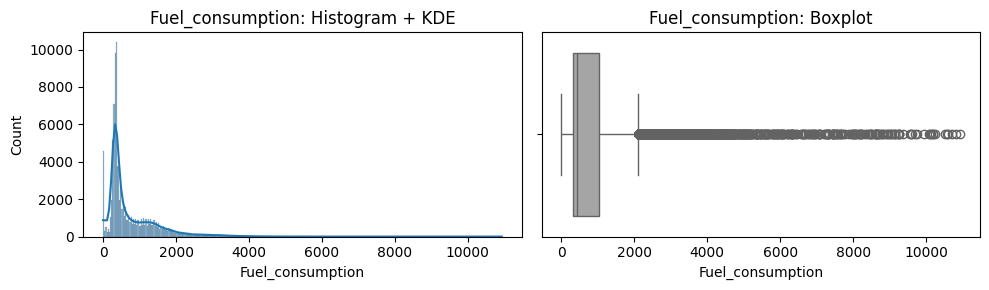

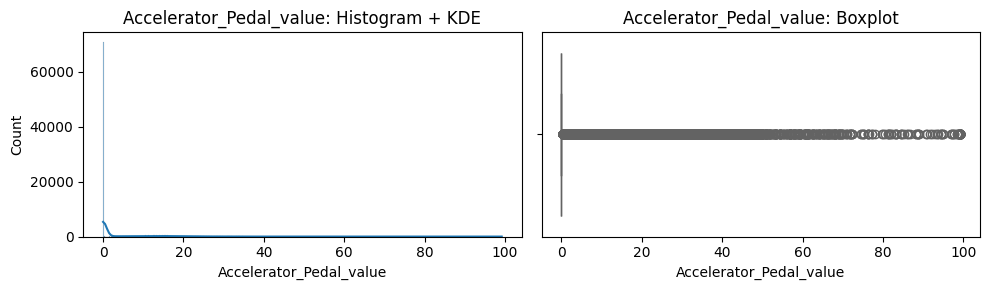

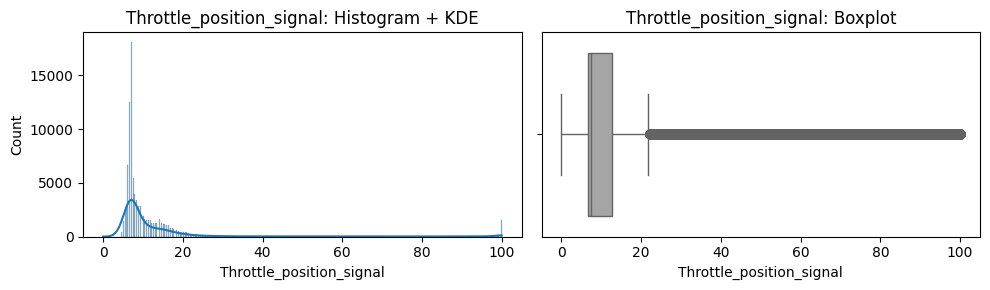

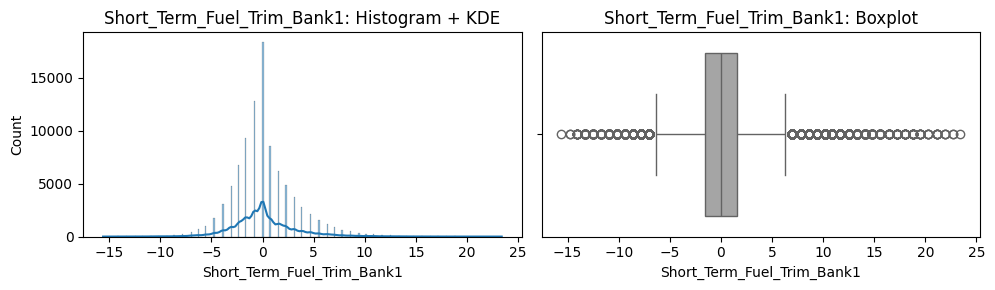

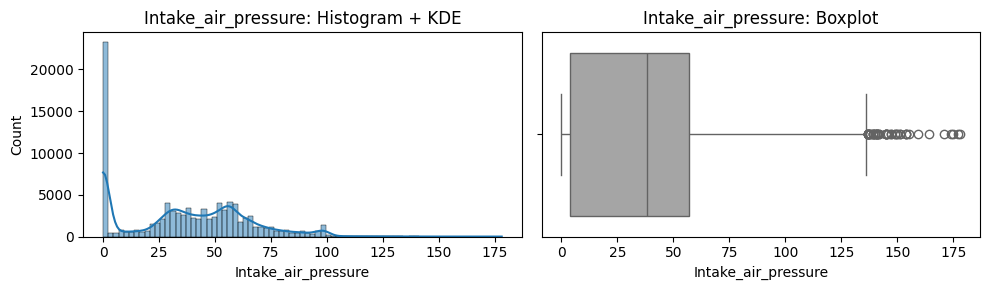

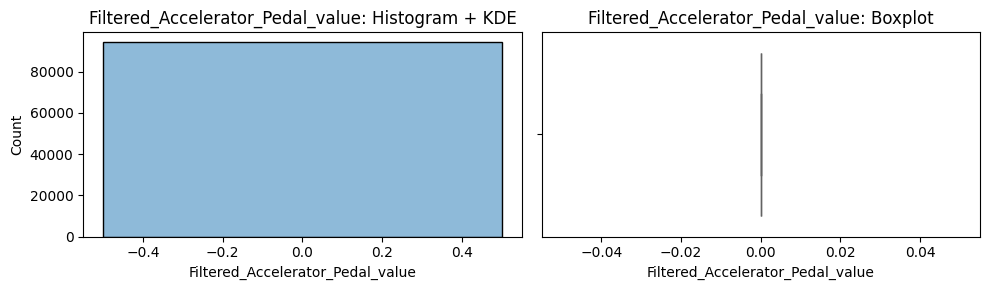

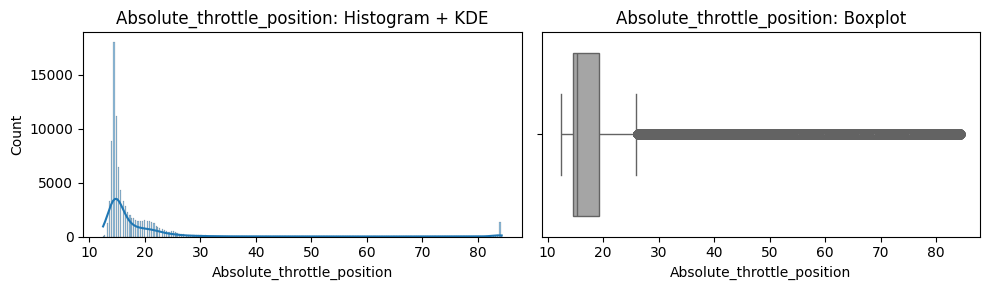

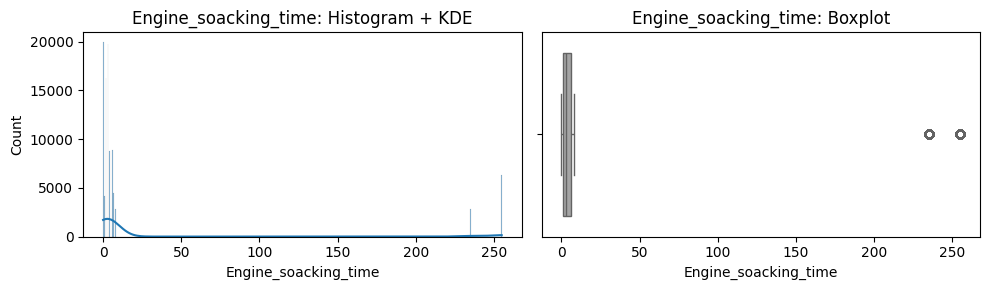

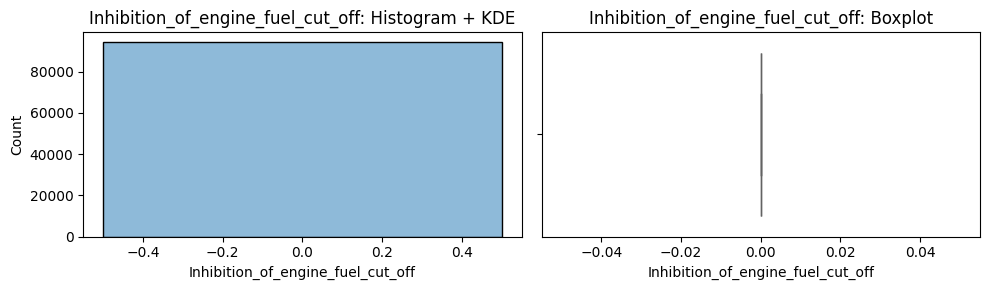

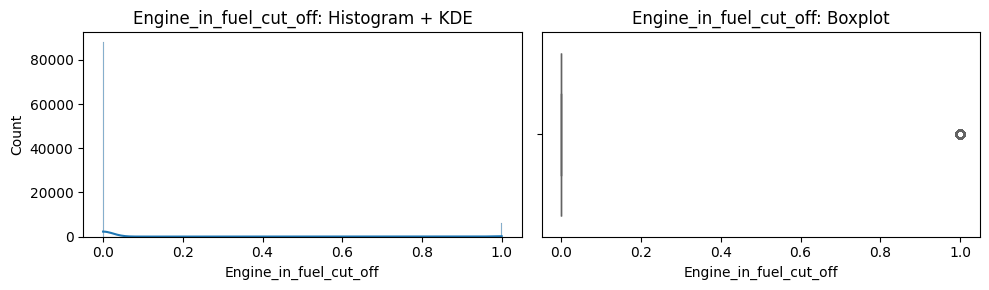

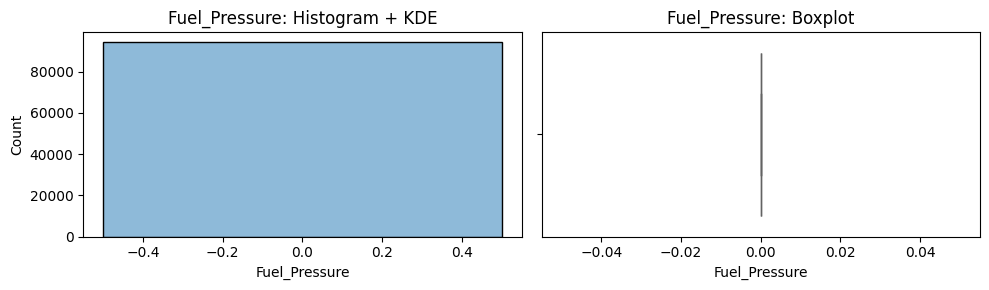

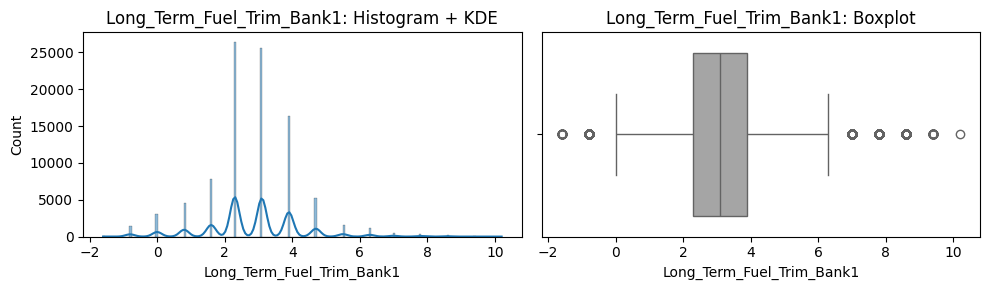

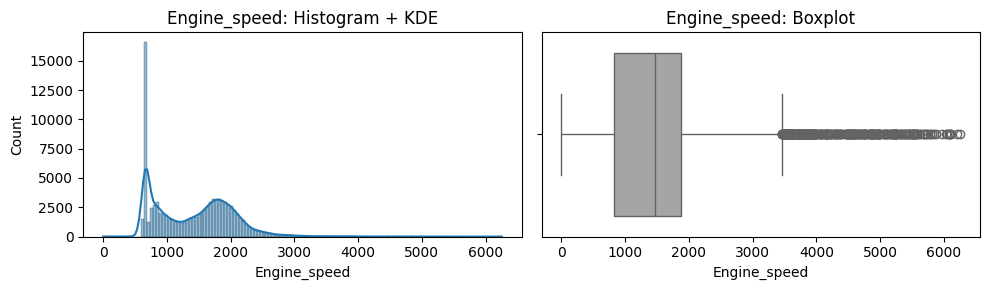

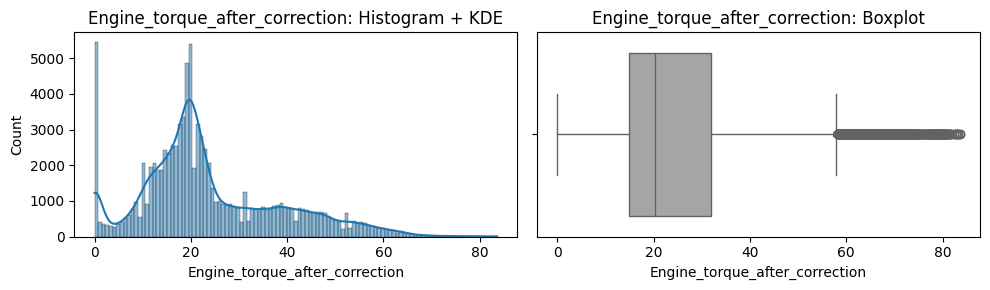

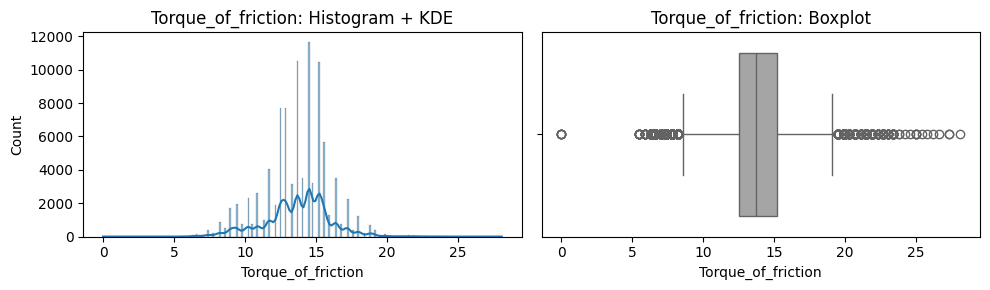

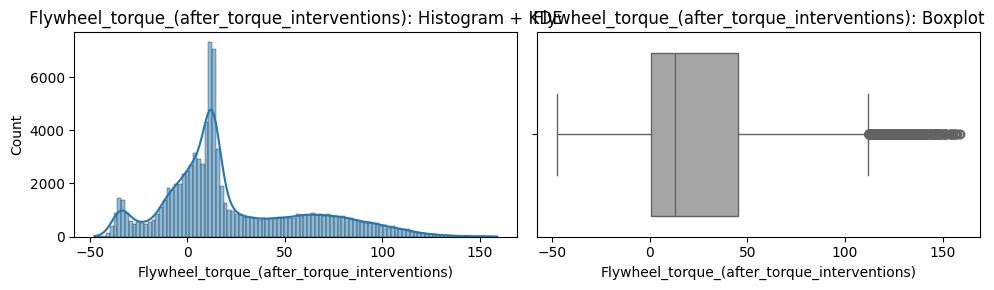

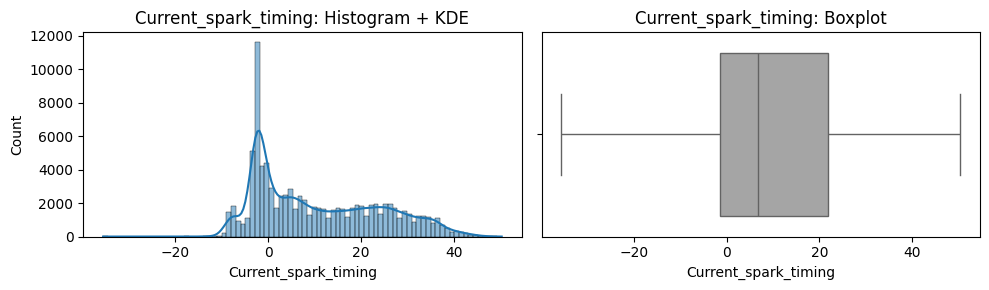

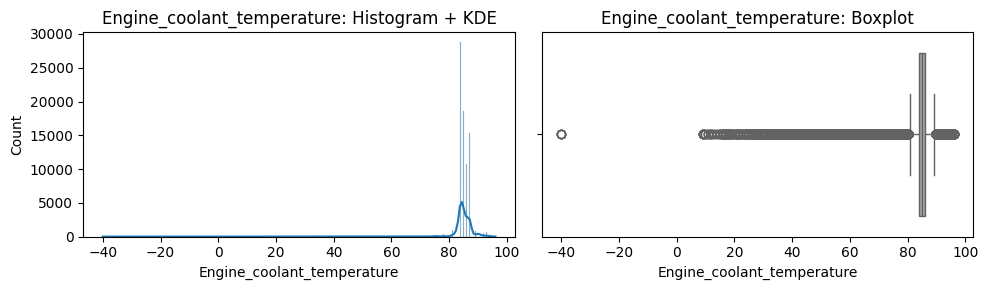

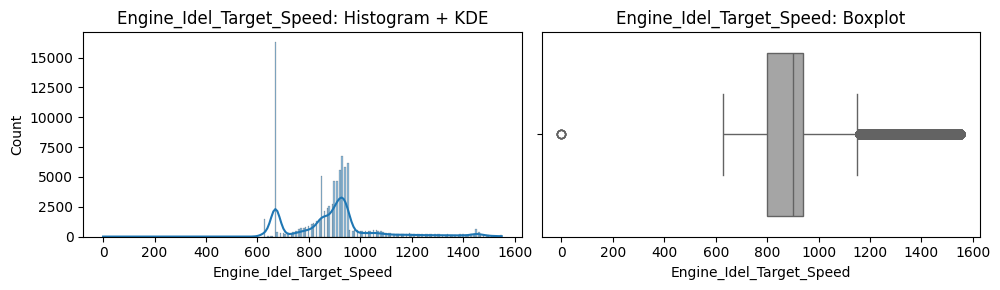

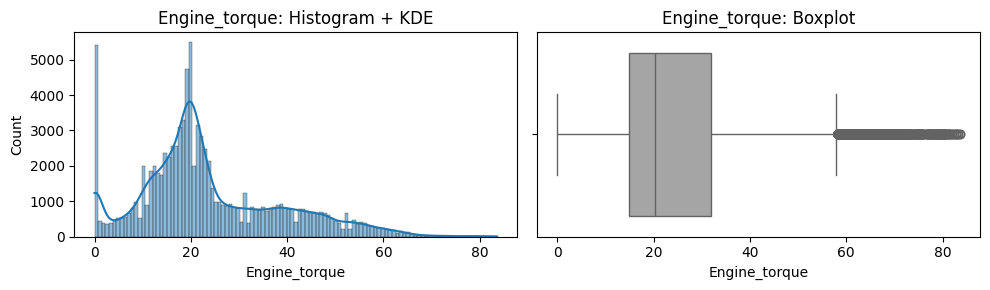

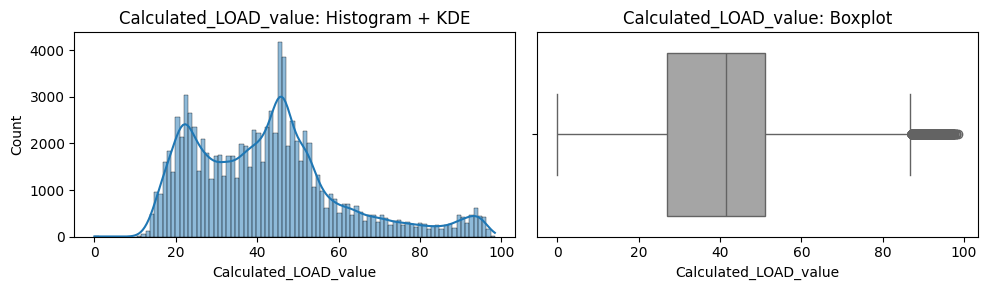

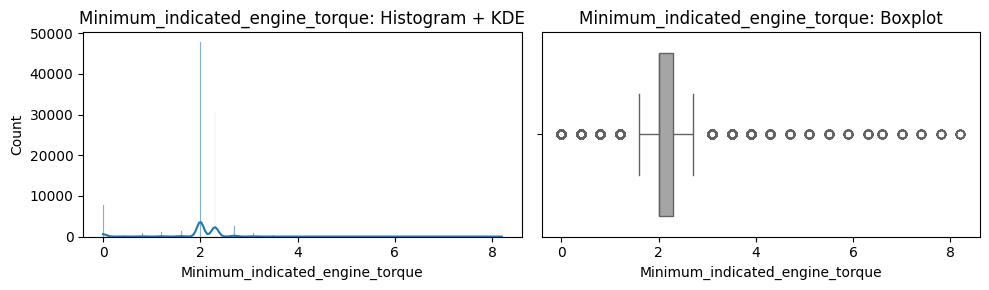

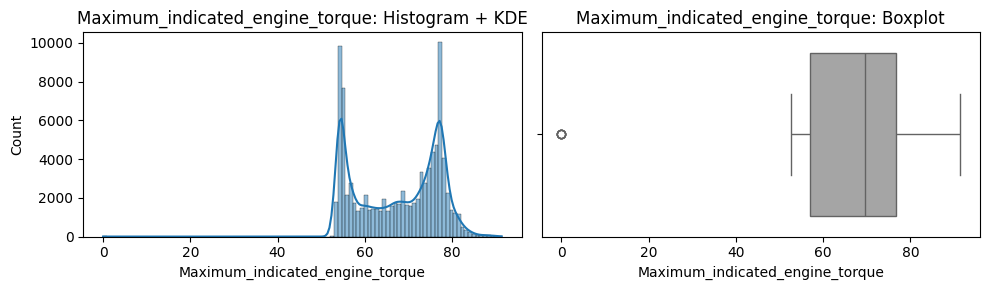

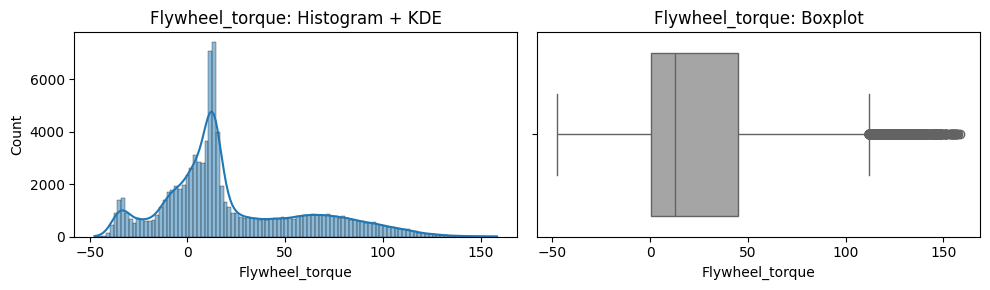

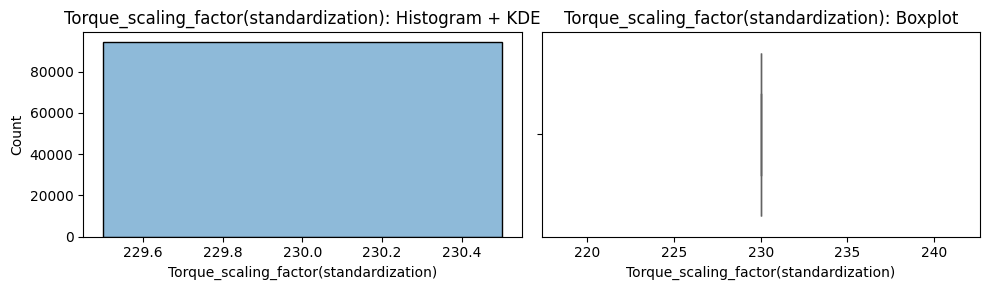

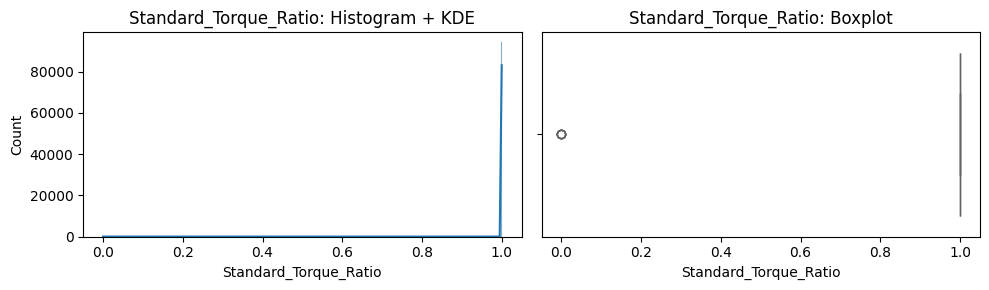

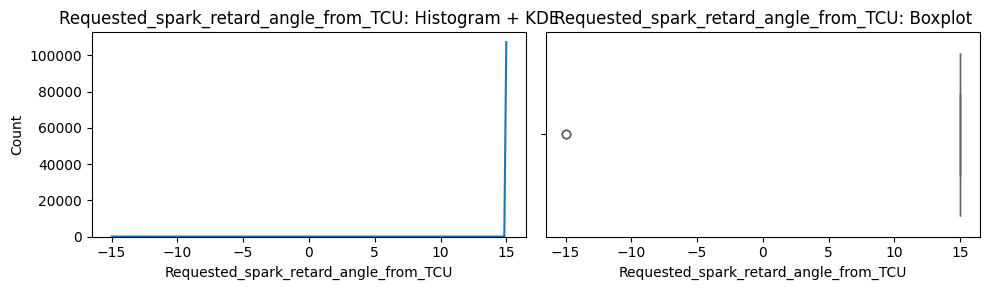

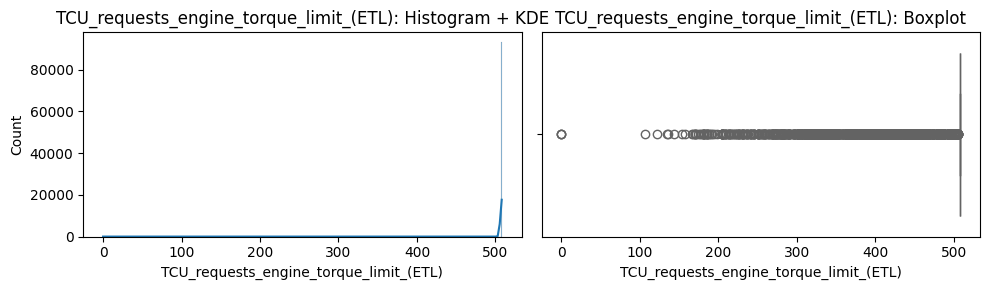

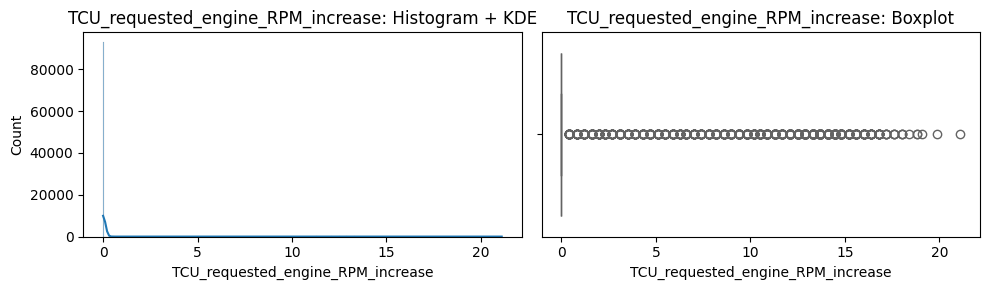

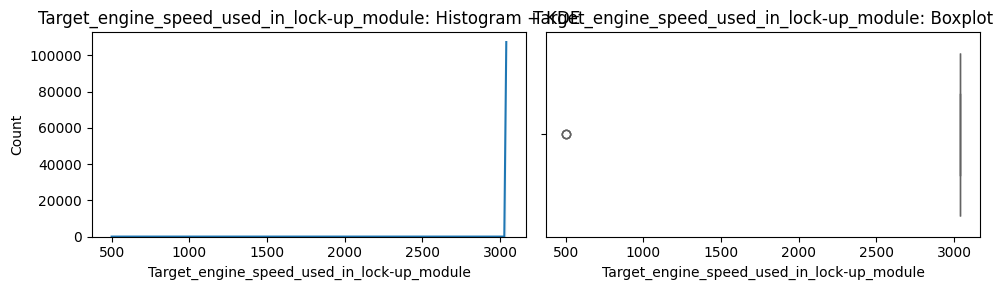

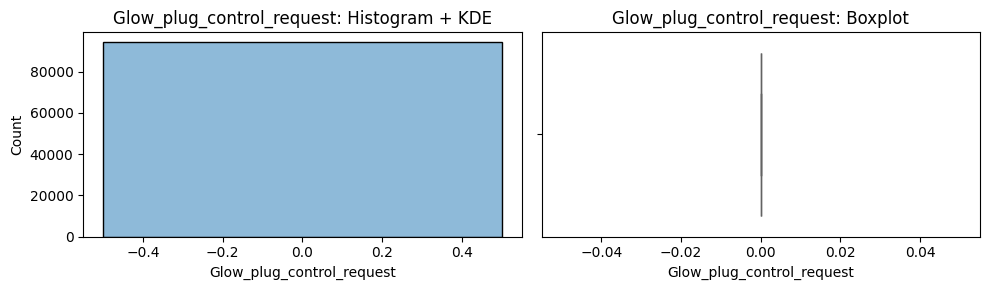

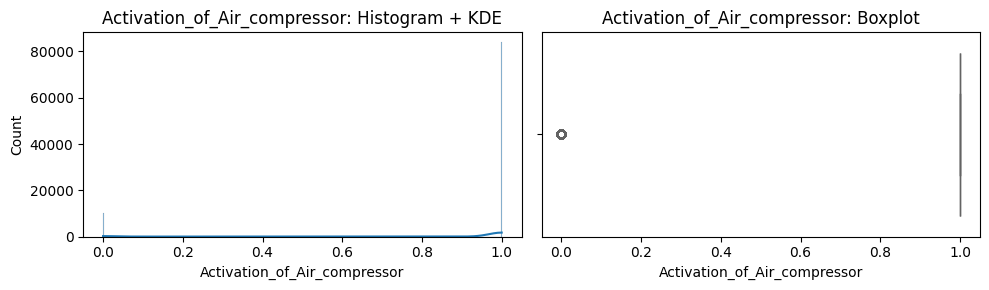

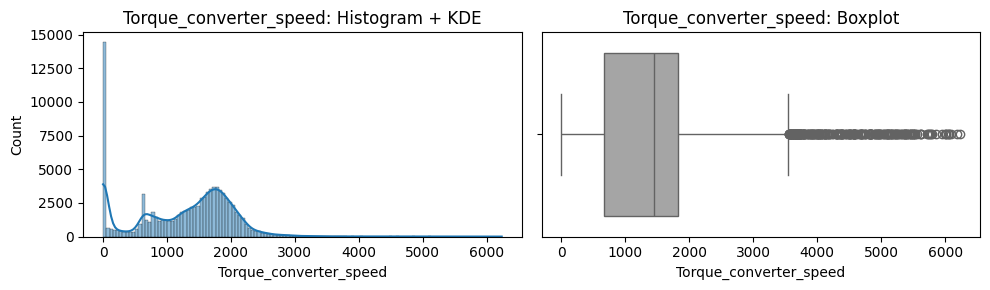

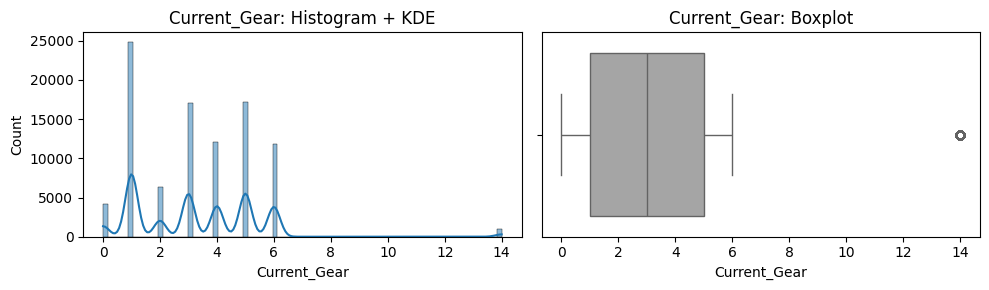

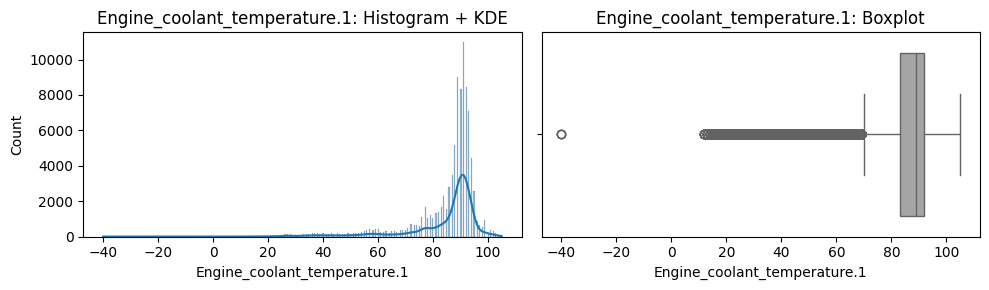

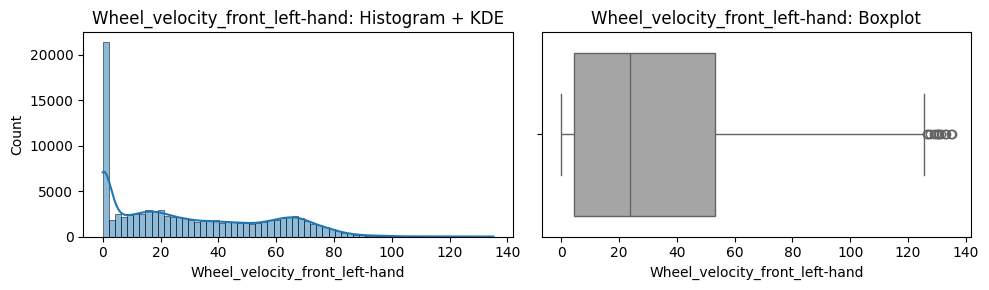

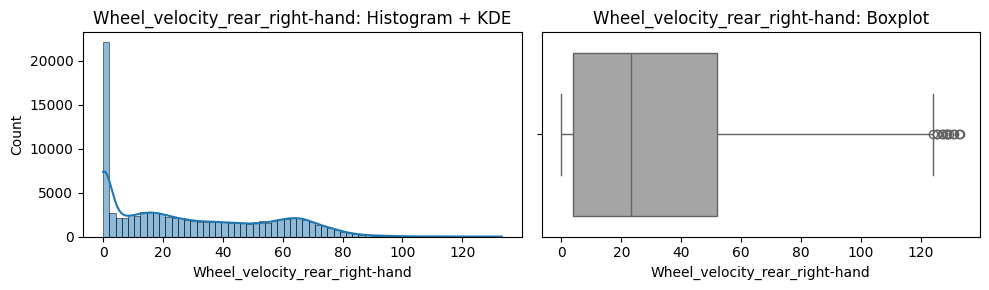

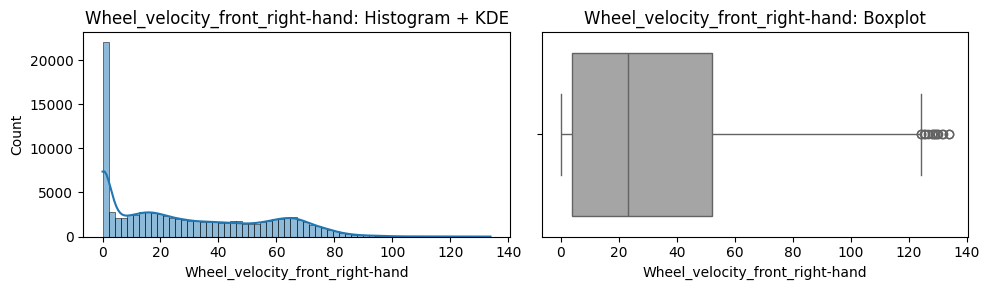

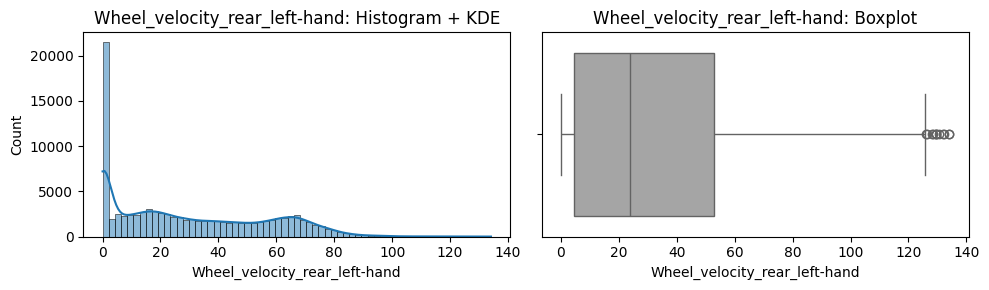

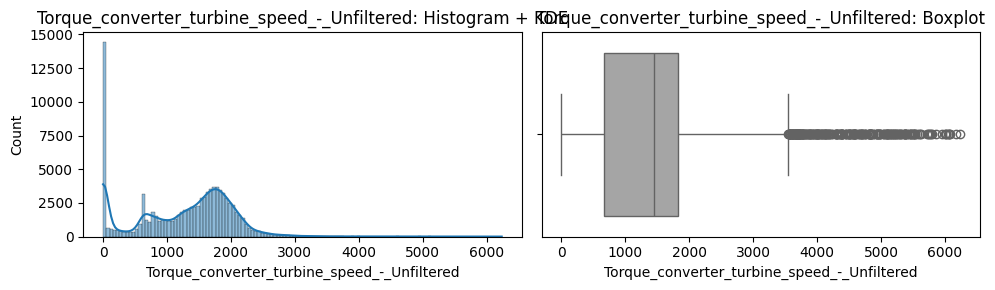

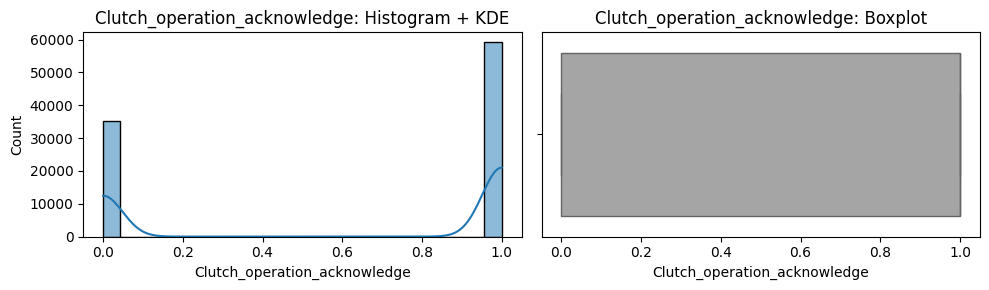

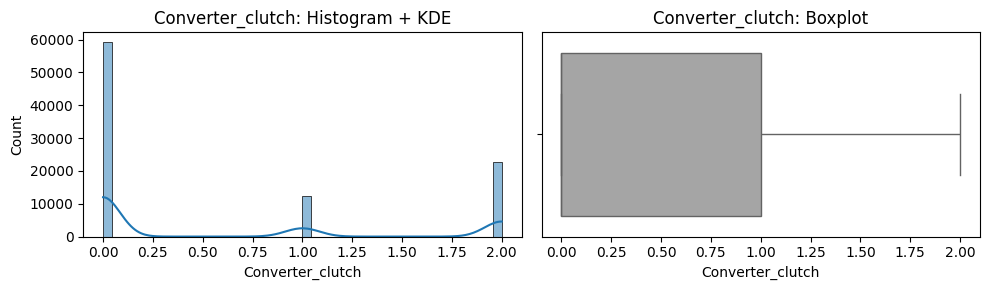

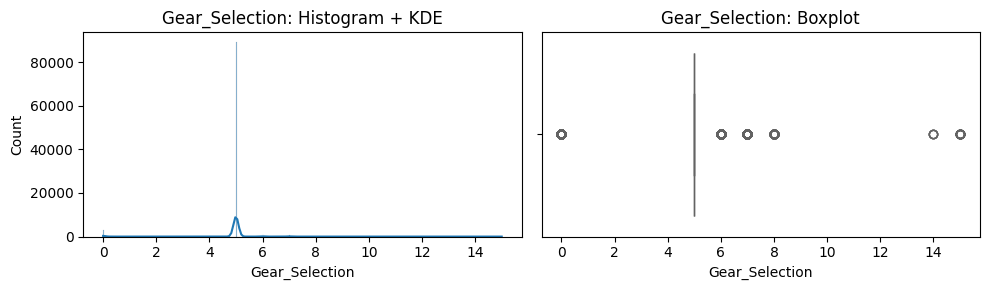

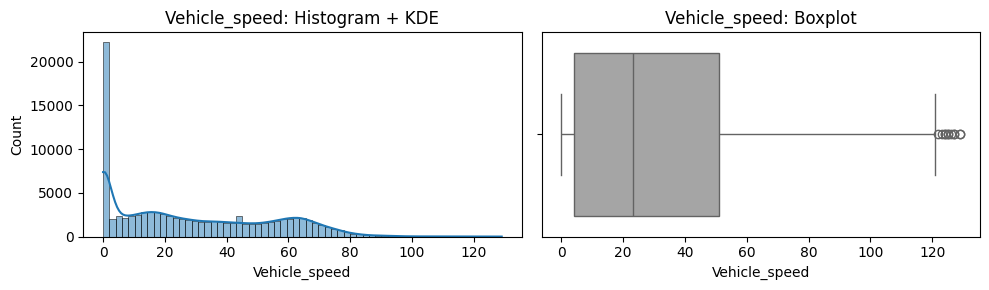

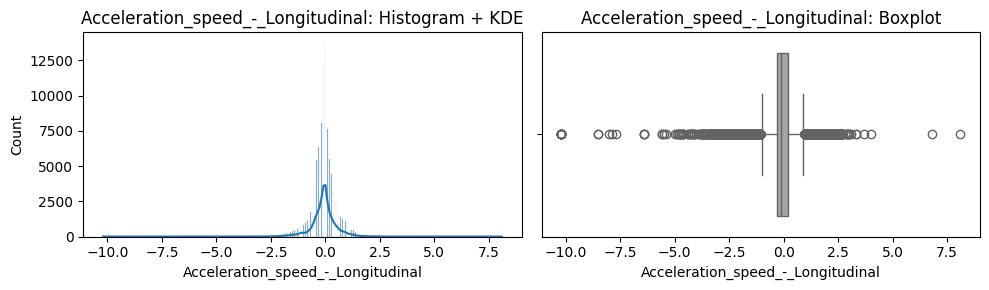

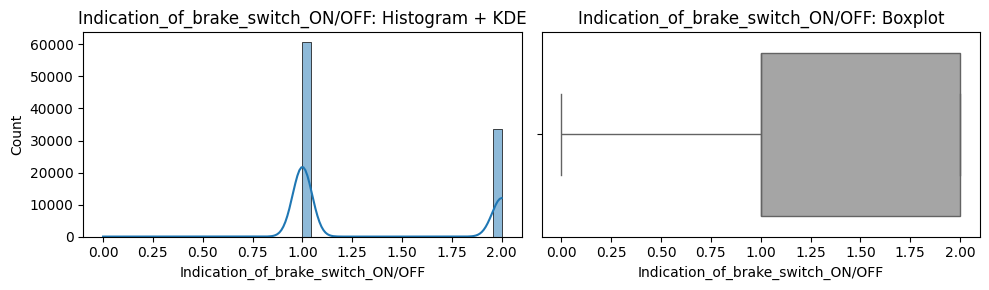

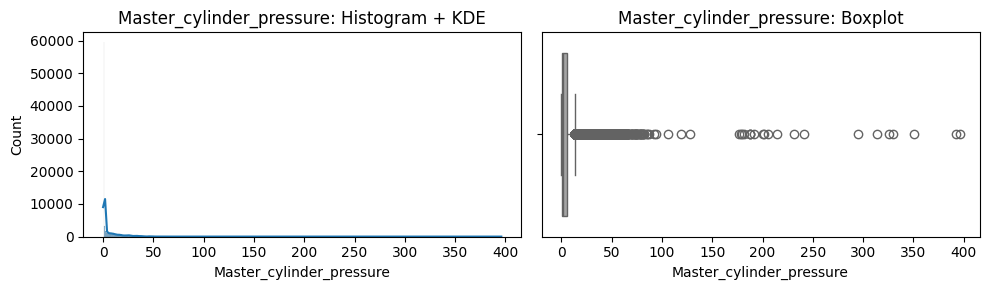

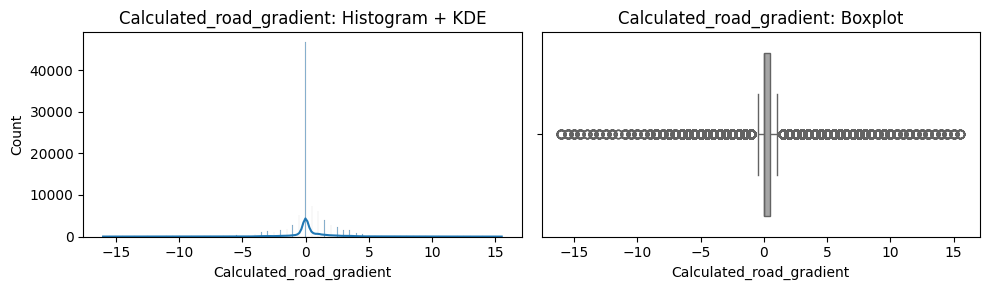

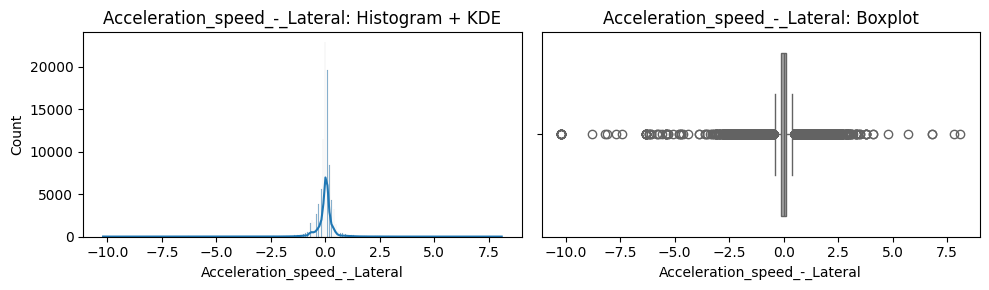

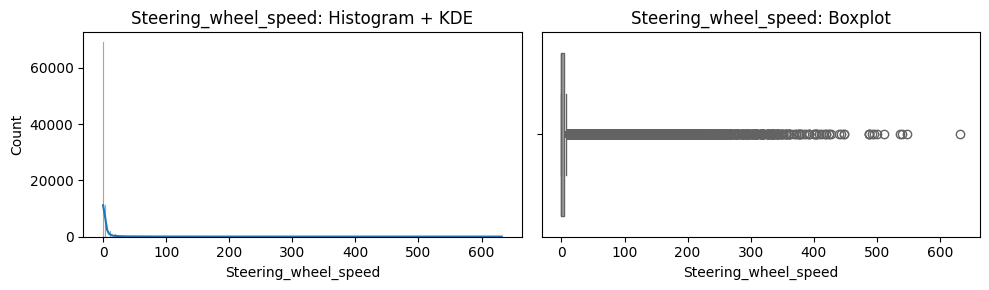

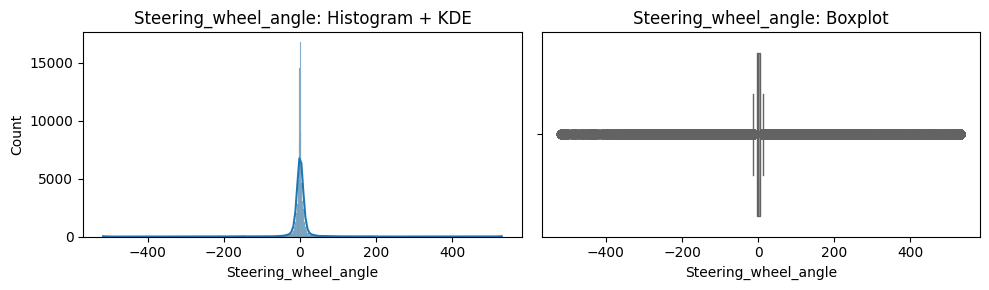

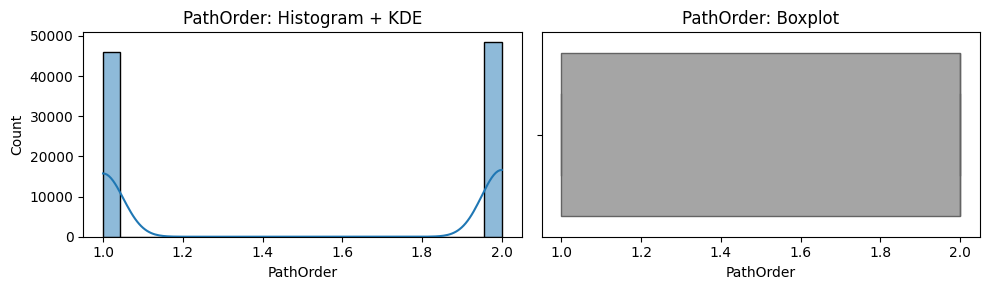

,count,mean,std,min,25%,50%,75%,max,skew,outlier_count,outlier_pct
Fuel_consumption,94380.0,757.000246,761.376214,0.0,320.0,422.40,1036.80,10931.2,2.896893,5363,5.682348
Accelerator_Pedal_value,94380.0,3.718682,8.505756,0.0,0.0,0.00,0.00,99.2,3.640442,23529,24.930070
Throttle_position_signal,94380.0,13.208186,16.262249,0.0,6.6,7.50,12.70,100.0,4.157294,7556,8.005933
Short_Term_Fuel_Trim_Bank1,94380.0,0.122782,3.166412,-15.6,-1.6,0.00,1.60,23.4,0.796784,4742,5.024370
Intake_air_pressure,94380.0,36.853433,27.957584,0.0,4.0,38.00,57.00,178.0,0.214383,49,0.051918
Filtered_Accelerator_Pedal_value,94380.0,0.000000,0.000000,0.0,0.0,0.00,0.00,0.0,0.000000,0,0.000000
Absolute_throttle_position,94380.0,19.362277,12.079046,12.5,14.5,15.30,19.20,84.3,4.141676,7393,7.833227
Engine_soacking_time,94380.0,26.795327,73.072712,0.0,1.0,3.00,6.00,255.0,2.715942,9208,9.756304
Inhibition_of_engine_fuel_cut_off,94380.0,0.000000,0.000000,0.0,0.0,0.00,0.00,0.0,0.000000,0,0.000000
Engine_in_fuel_cut_off,94380.0,0.067249,0.250455,0.0,0.0,0.00,0.00,1.0,3.455792,6347,6.724942


In [6]:
# Numeric features: histogram + KDE and boxplot
numeric_cols = [col for col in df_eda.select_dtypes(include=np.number).columns if col != 'Class' and col != 'Time(s)']

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    sns.histplot(df_eda[col], kde=True, ax=axes[0])
    axes[0].set_title(f'{col}: Histogram + KDE')
    sns.boxplot(x=df_eda[col], ax=axes[1], color='#A5A5A5')
    axes[1].set_title(f'{col}: Boxplot')
    plt.tight_layout()
    plt.show()

# Calculate outliers using IQR method for each column
def calculate_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((series < lower_bound) | (series > upper_bound)).sum()
    return outliers

outlier_counts = {col: calculate_outliers(df_eda[col]) for col in numeric_cols}
outlier_percentages = {col: (count / len(df_eda)) * 100 for col, count in outlier_counts.items()}

# Quick numeric summary to complement plots with outlier info
summary_table = df_eda[numeric_cols].describe().T.assign(
    skew=df_eda[numeric_cols].skew(),
    outlier_count=pd.Series(outlier_counts),
    outlier_pct=pd.Series(outlier_percentages)
)
display(summary_table)

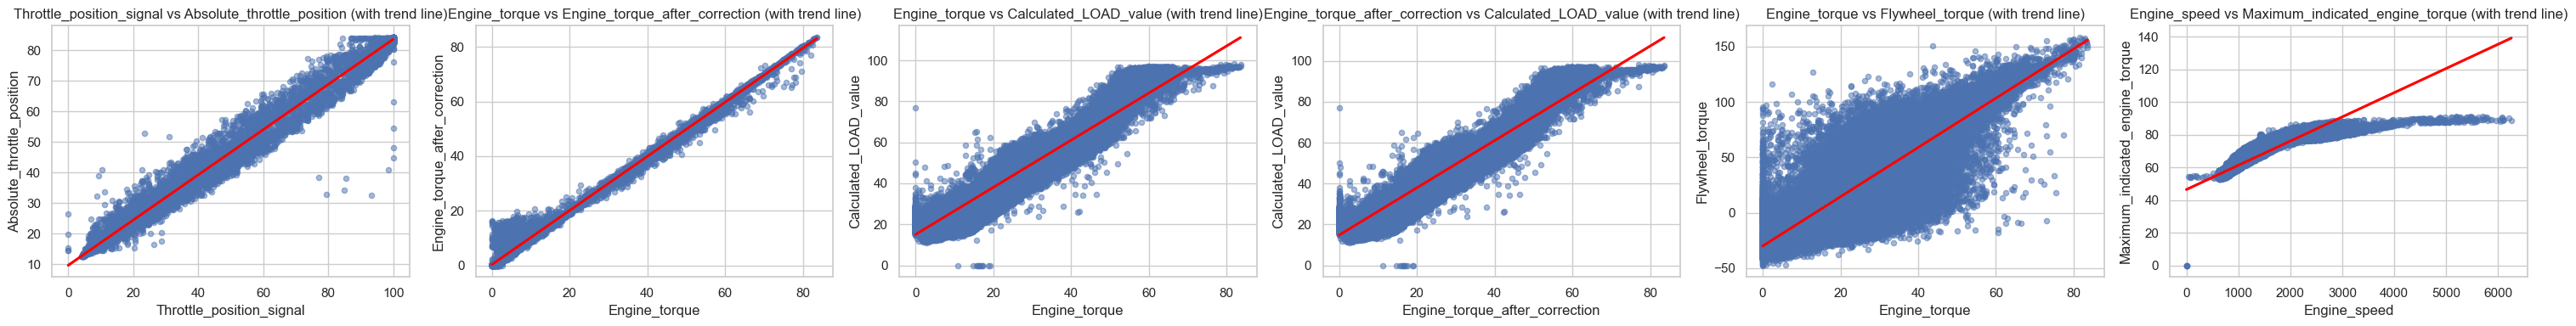

In [ ]:

pairs = [
    # Throttle / pedal family
    ('Throttle_position_signal', 'Absolute_throttle_position'),          # ~1.00 (near-duplicate)

    # Torque / load family
    ('Engine_torque', 'Engine_torque_after_correction'),                # ~1.00 (near-duplicate)
    ('Engine_torque', 'Calculated_LOAD_value'),                         # ~0.92
    ('Engine_torque_after_correction', 'Calculated_LOAD_value'),         # ~0.92
    ('Engine_torque', 'Flywheel_torque'),                               # ~0.89
  
    # Engine speed vs torque indicator
    ('Engine_speed', 'Maximum_indicated_engine_torque'),                # ~0.95
]


# Check if all columns exist in df_eda
missing_cols = [col for pair in pairs for col in pair if col not in df_eda.columns]
if missing_cols:
    print(f"Missing columns in df_eda: {missing_cols}")
else:
    fig, axes = plt.subplots(1, len(pairs), figsize=(5*len(pairs), 4))
    for ax, (x, y) in zip(axes, pairs):
        sns.regplot(data=df_eda, x=x, y=y, scatter_kws={'s': 20, 'alpha': 0.5}, line_kws={'color': 'red'}, ax=ax)
        ax.set_title(f'{x} vs {y} (with trend line)')
    plt.tight_layout()
    plt.show()

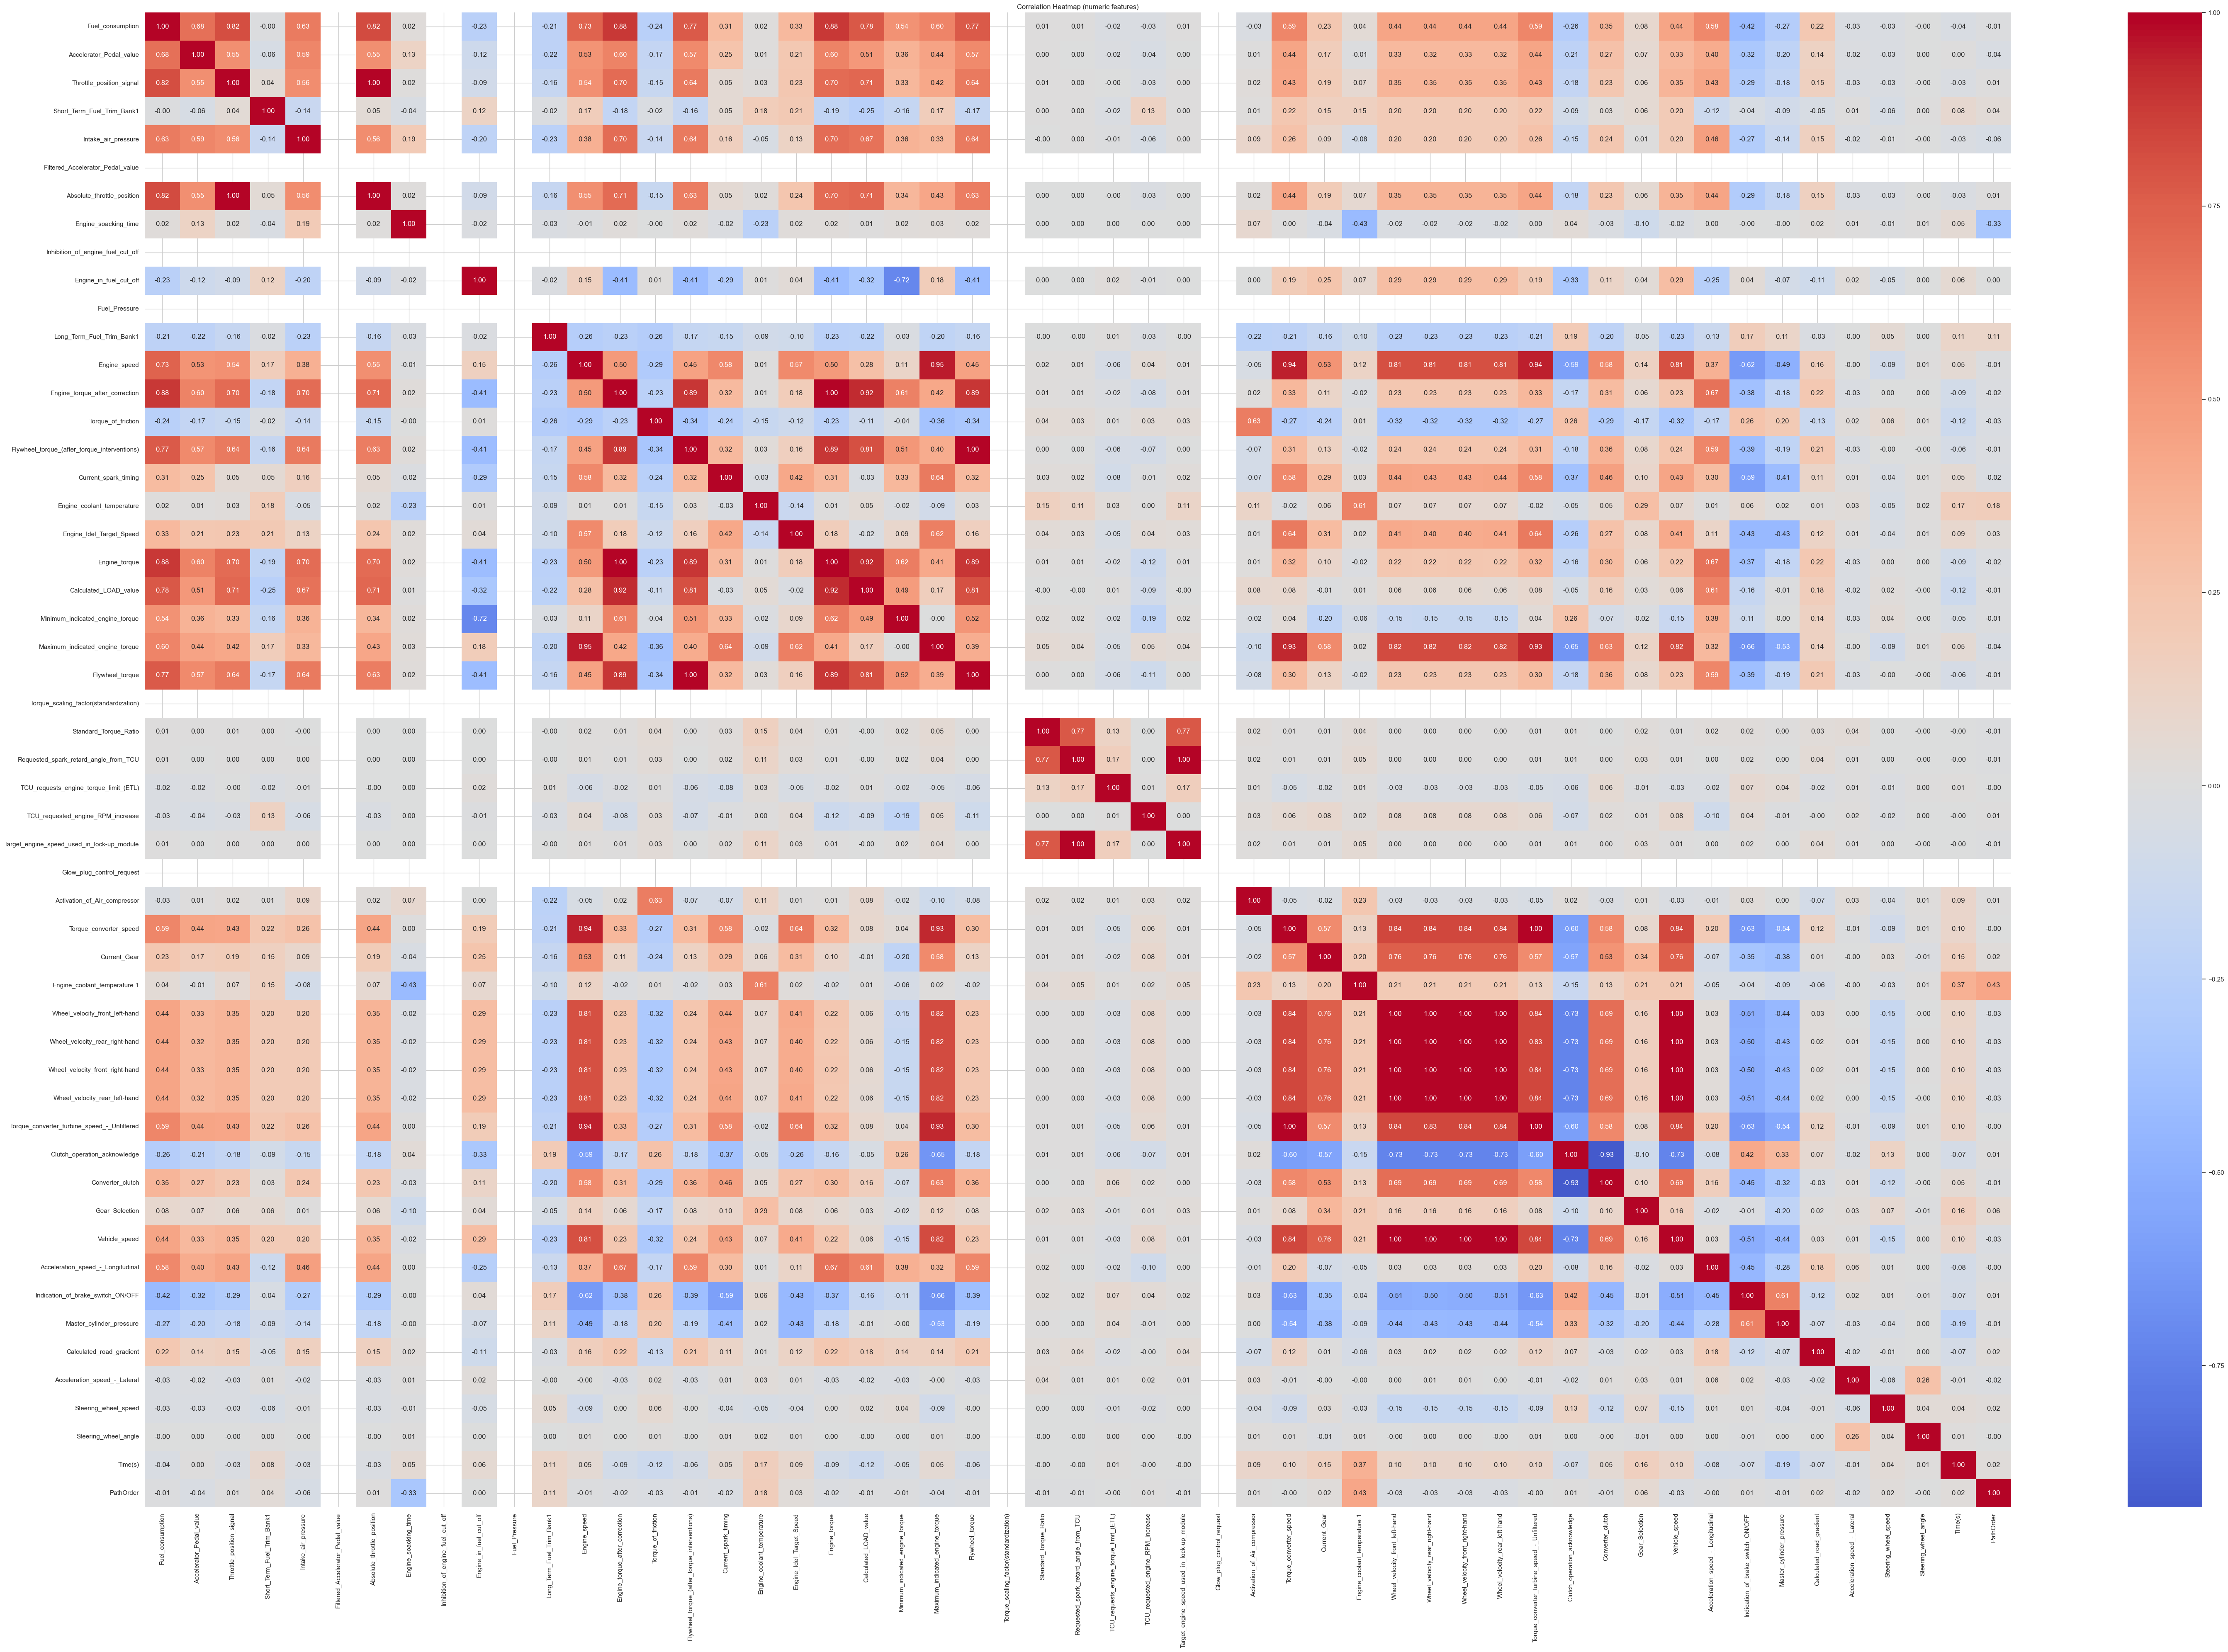

In [9]:
num_df = df_eda.select_dtypes(include='number')
plt.figure(figsize=(60, 40))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (numeric features)')
plt.tight_layout()
plt.show()

## now we can start with changing the data 
Remove non-informative features (closed to 0 var and same values features) cz they do give any usfule infos
Handle highly correlated features (we can use random forest that is good with correlation or keep one feature from ones that are very correlated)
Outlier handling
Feature scaling


In [23]:
df = pd.read_csv("../data/transformed/Driving Data(KIA SOUL)_(150728-160714)_(10 Drivers_A-J).csv")
# drop the columns wheel_velocity_FL, wheel_velocity_FR, wheel_velocity_RL
df = df.drop(columns=['Wheel_velocity_rear_right-hand', 'Wheel_velocity_front_left-hand', 'Wheel_velocity_rear_left-hand' , 'Glow_plug_control_request' , 'Torque_scaling_factor(standardization)' , 'Fuel_Pressure' , 'Inhibition_of_engine_fuel_cut_off' ,'Filtered_Accelerator_Pedal_value'])
df.head()



,Fuel_consumption,Accelerator_Pedal_value,Throttle_position_signal,Short_Term_Fuel_Trim_Bank1,Intake_air_pressure,Absolute_throttle_position,Engine_soacking_time,Engine_in_fuel_cut_off,Long_Term_Fuel_Trim_Bank1,Engine_speed,Engine_torque_after_correction,Torque_of_friction,Flywheel_torque_(after_torque_interventions),Current_spark_timing,Engine_coolant_temperature,Engine_Idel_Target_Speed,Engine_torque,Calculated_LOAD_value,Minimum_indicated_engine_torque,Maximum_indicated_engine_torque,Flywheel_torque,Standard_Torque_Ratio,Requested_spark_retard_angle_from_TCU,TCU_requests_engine_torque_limit_(ETL),TCU_requested_engine_RPM_increase,Target_engine_speed_used_in_lock-up_module,Activation_of_Air_compressor,Torque_converter_speed,Current_Gear,Engine_coolant_temperature.1,Wheel_velocity_front_right-hand,Torque_converter_turbine_speed_-_Unfiltered,Clutch_operation_acknowledge,Converter_clutch,Gear_Selection,Vehicle_speed,Acceleration_speed_-_Longitudinal,Indication_of_brake_switch_ON/OFF,Master_cylinder_pressure,Calculated_road_gradient,Acceleration_speed_-_Lateral,Steering_wheel_speed,Steering_wheel_angle,Time(s),Class,PathOrder
0,268.8,0.0,5.2,0.0,33,13.3,3,0,-0.8,929,5.5,9.0,-5.9,-8.6,95,650,5.5,23.9,2.0,58.2,-5.9,1,15,508,0.0,3040,0,939.3,0,87,0.0,935.5,1,0,0,0,-8.5,1,325.5,0.0,-8.8,0,-3.4,1,A,1
1,243.2,0.0,6.1,0.0,40,13.7,3,0,-0.8,726,7.0,7.8,1.7,-11.3,95,670,7.0,30.6,2.0,53.9,1.8,1,15,508,0.0,3040,0,710.0,0,87,0.0,709.5,1,0,0,0,0.1,1,0.9,0.0,-0.2,0,-3.6,2,A,1
2,217.6,0.0,5.2,0.0,41,13.7,3,0,-0.8,685,7.0,7.4,-3.0,-12.8,95,670,7.0,31.8,2.0,53.1,-2.8,1,15,508,0.0,3040,0,663.3,0,87,0.0,663.5,1,0,0,0,0.1,1,0.9,0.0,-0.2,0,-3.6,3,A,1
3,204.8,0.0,4.7,0.0,38,13.3,3,0,-0.8,675,7.0,6.6,-1.3,-9.8,95,670,7.0,29.0,2.0,53.1,-1.2,1,15,508,0.0,3040,0,652.5,0,87,0.0,653.0,1,0,0,0,0.1,1,0.9,0.0,-0.2,0,-3.6,4,A,1
4,217.6,0.0,5.7,0.0,40,13.7,3,0,-0.8,716,8.2,11.3,-15.6,-7.9,95,670,8.2,30.2,2.0,53.5,-15.9,1,15,508,0.0,3040,1,692.5,0,87,0.0,693.8,1,0,0,0,0.1,1,0.9,0.0,-0.2,0,-3.5,5,A,1


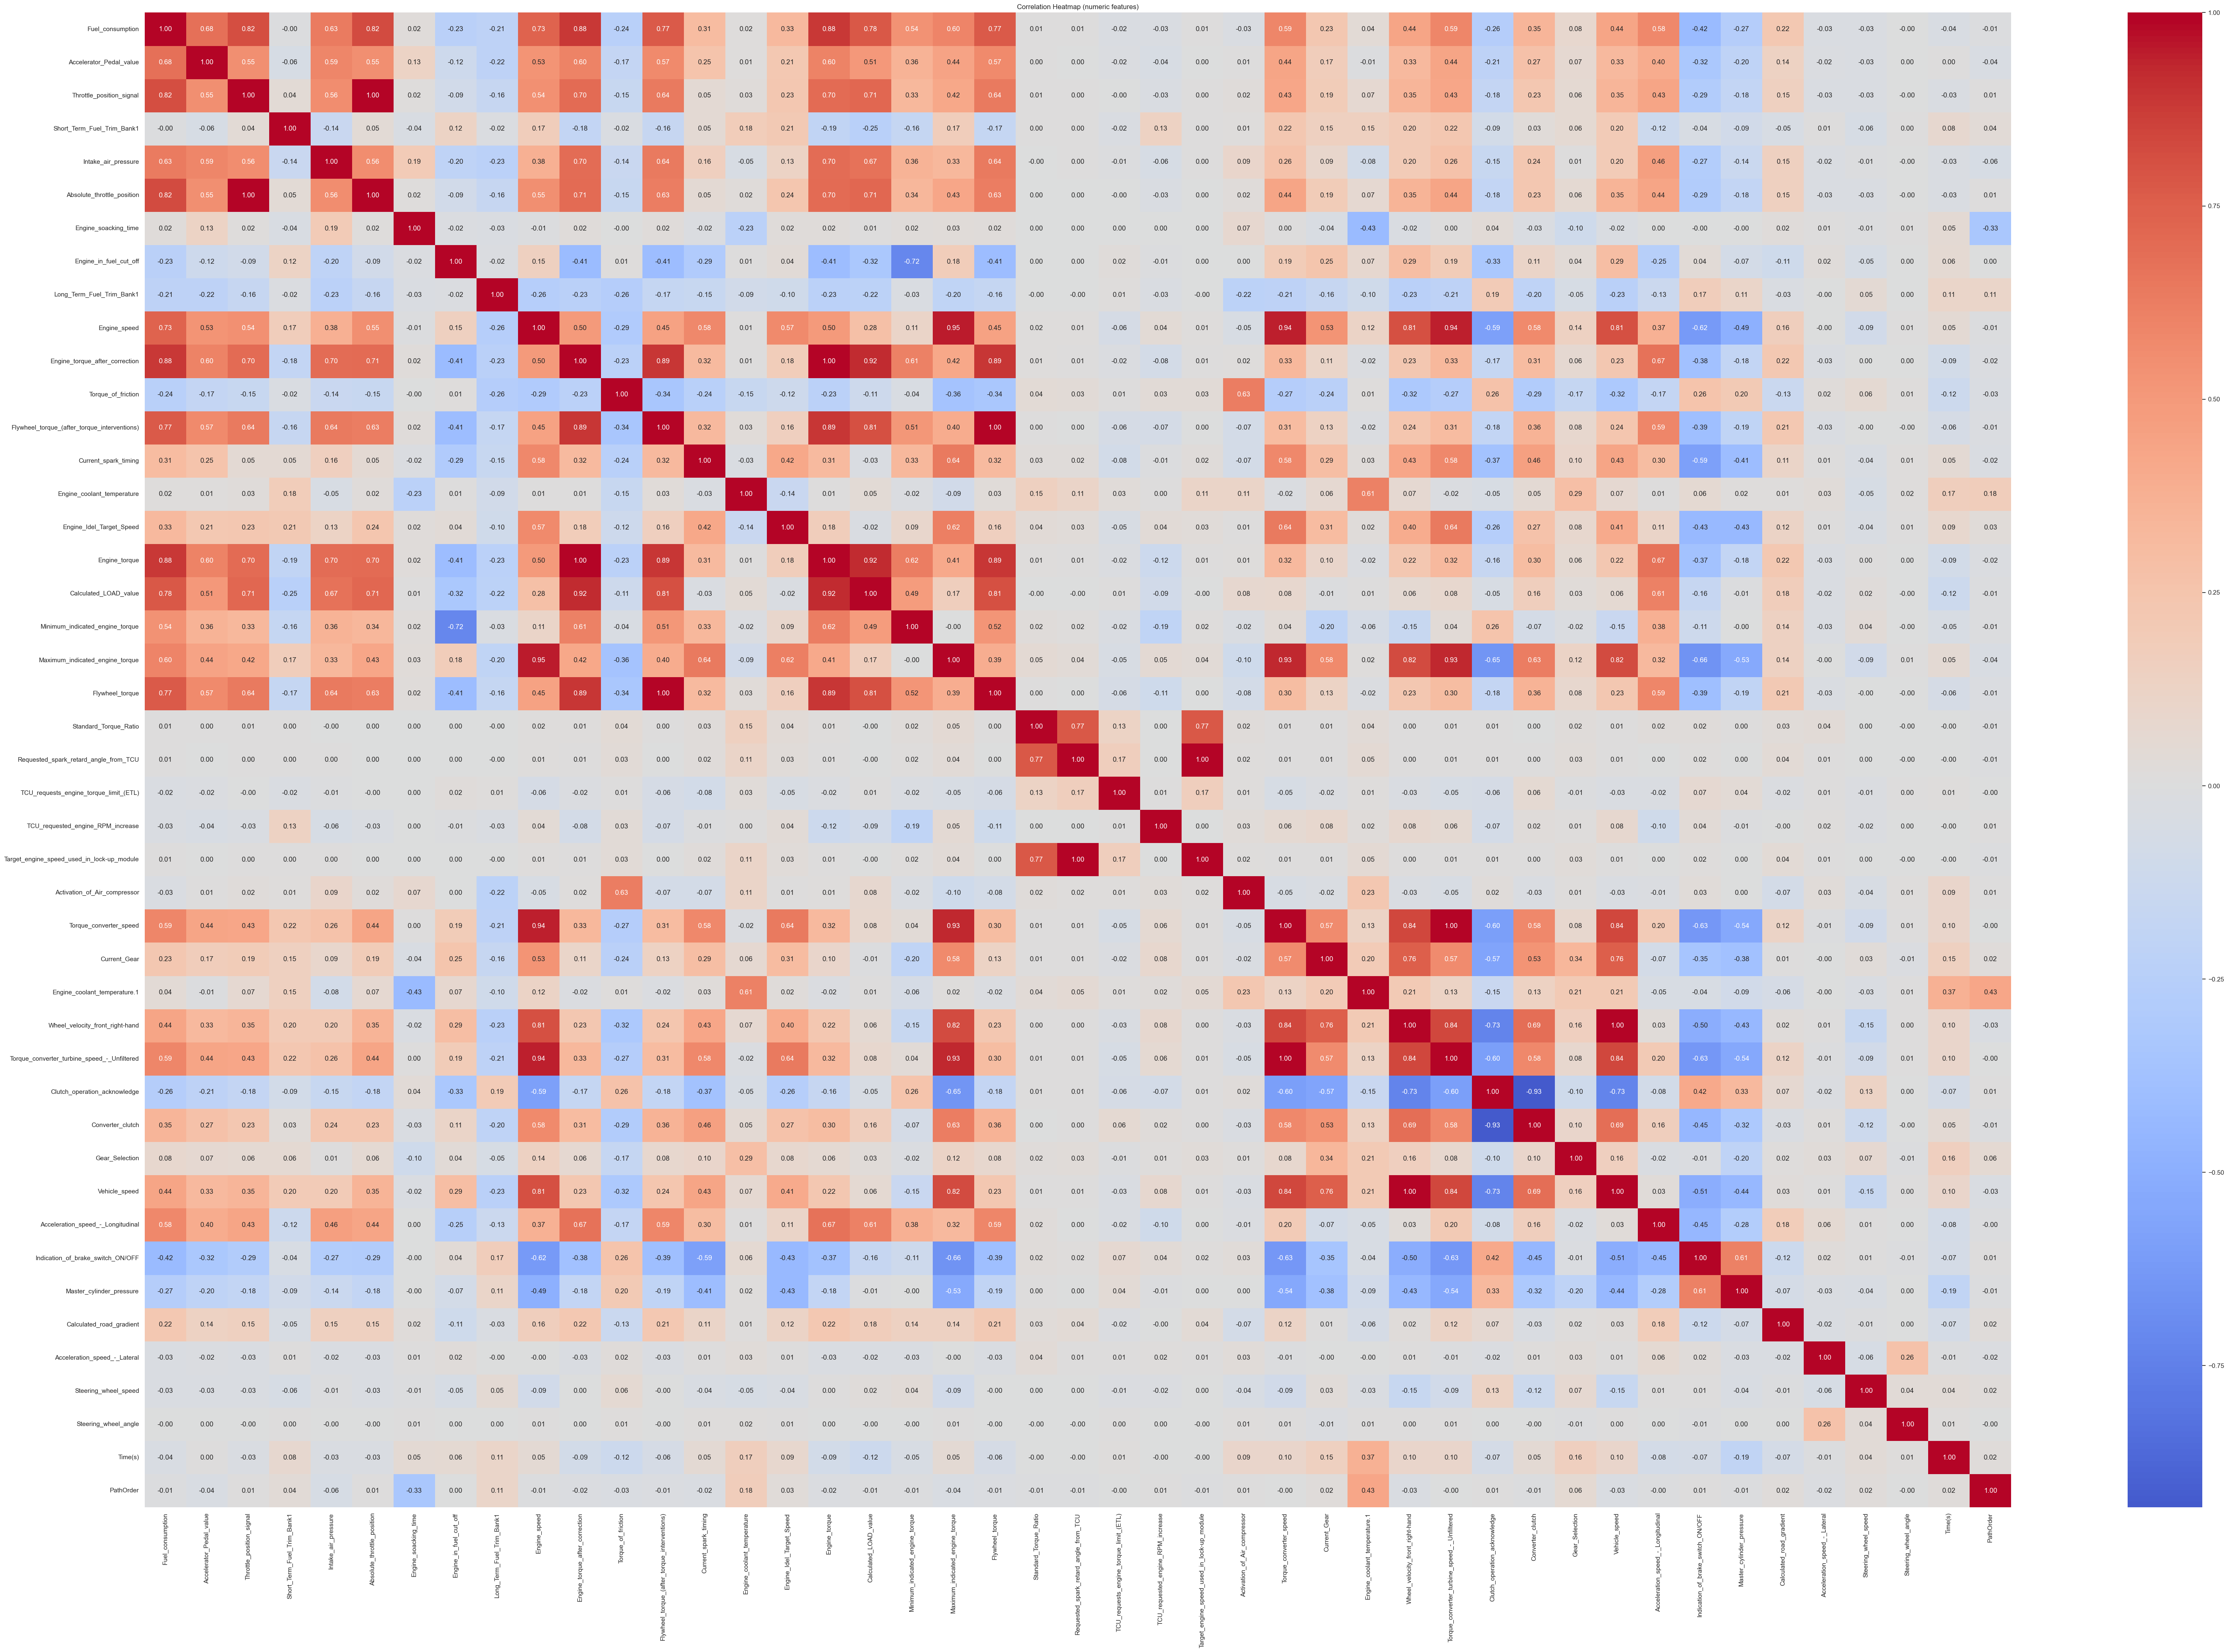

In [24]:
num_df = df.select_dtypes(include='number')
plt.figure(figsize=(60, 40))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (numeric features)')
plt.tight_layout()
plt.show()